In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn datasets and tools
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
data= load_diabetes(as_frame=True)

In [3]:
df=data.frame

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [15]:
categorical_cols = ["sex"]
numerical_cols = [col for col in df.columns if col not in categorical_cols + ["target"]]

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['sex']
Numerical: ['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


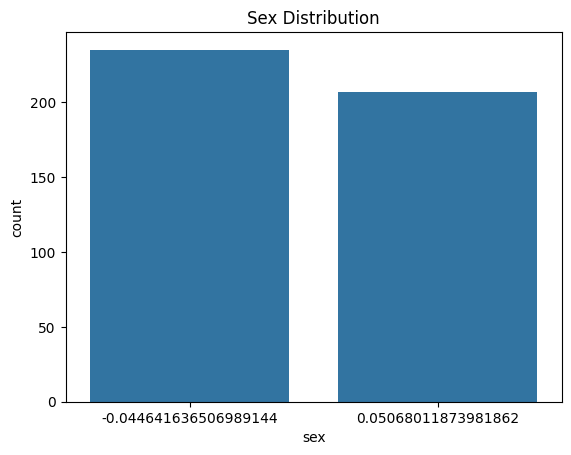

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["sex"])
plt.title("Sex Distribution")
plt.show()

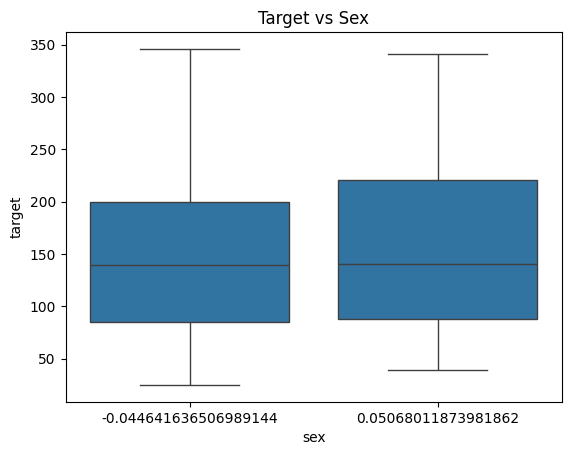

In [17]:
sns.boxplot(x=df["sex"], y=df["target"])
plt.title("Target vs Sex")
plt.show()

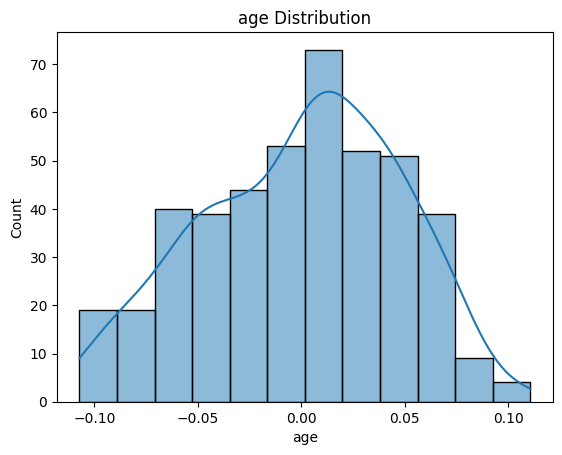

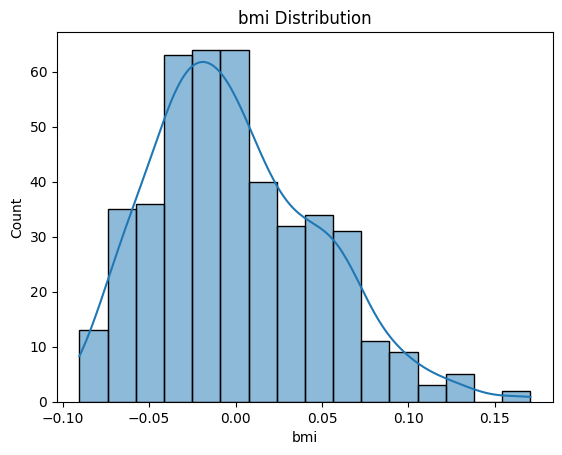

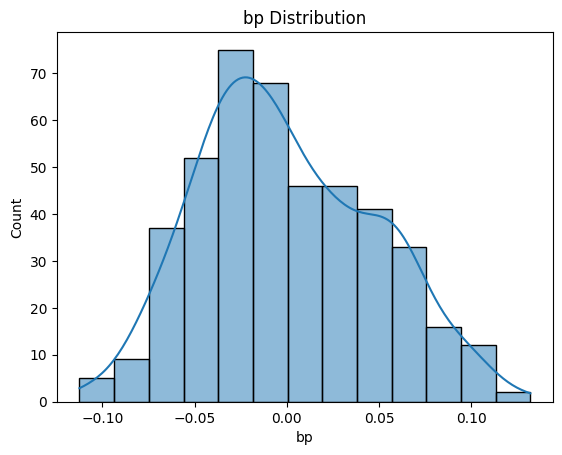

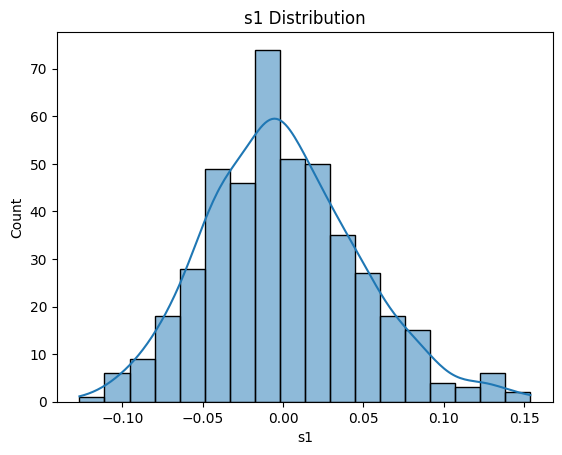

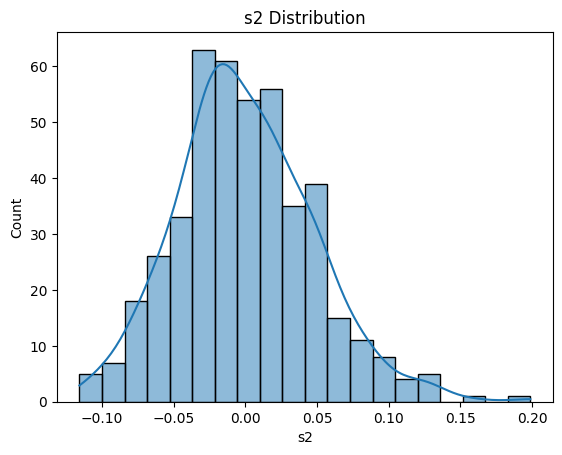

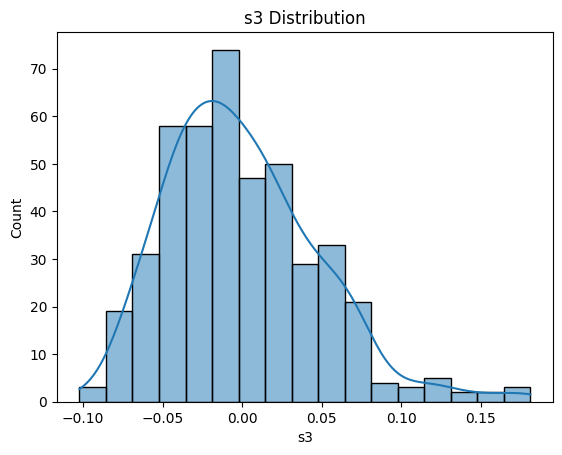

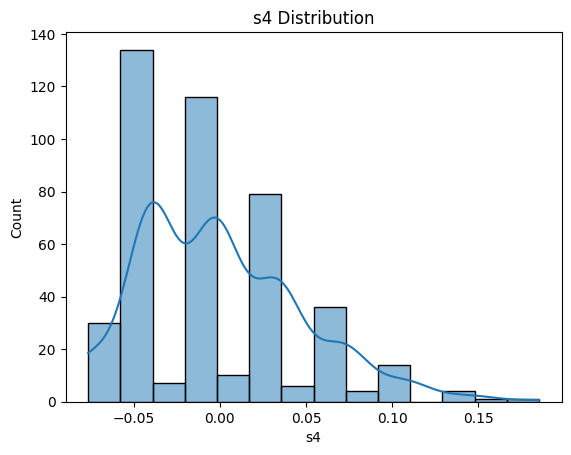

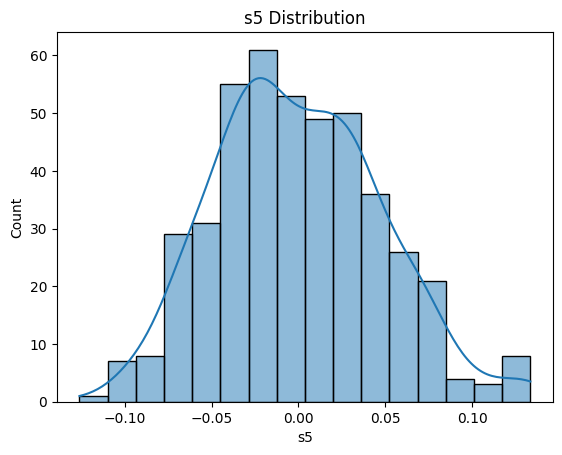

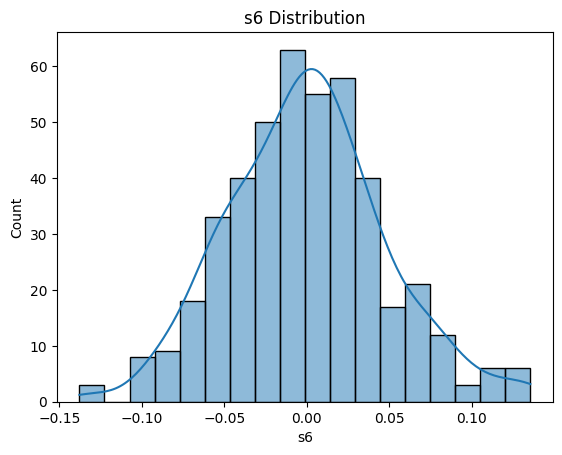

In [18]:
for col in numerical_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

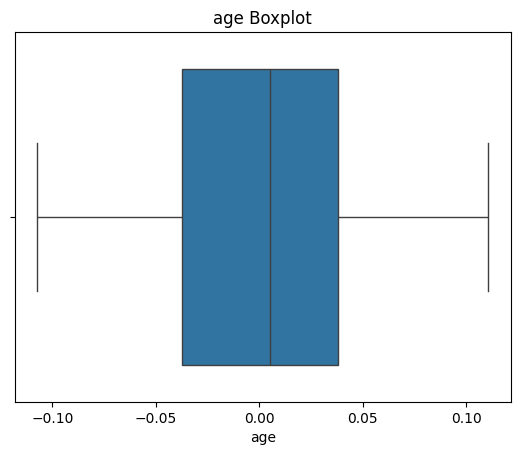

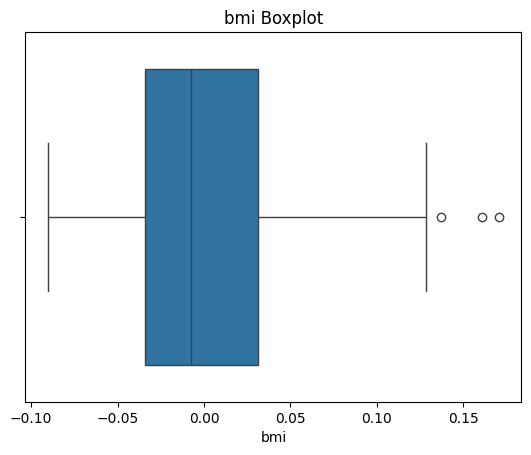

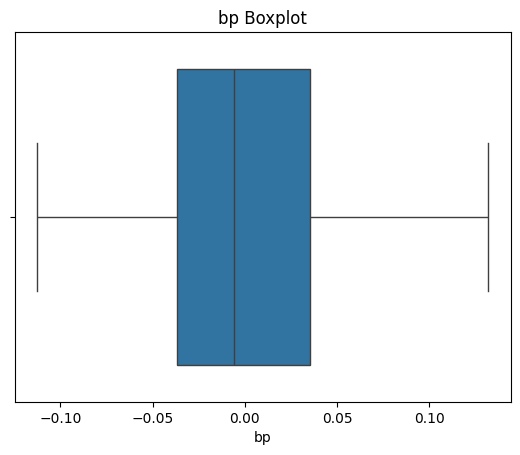

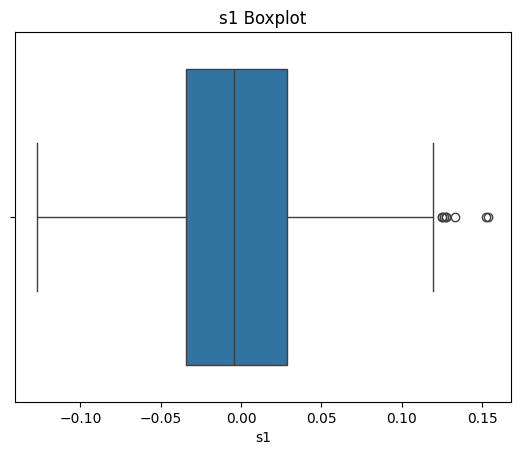

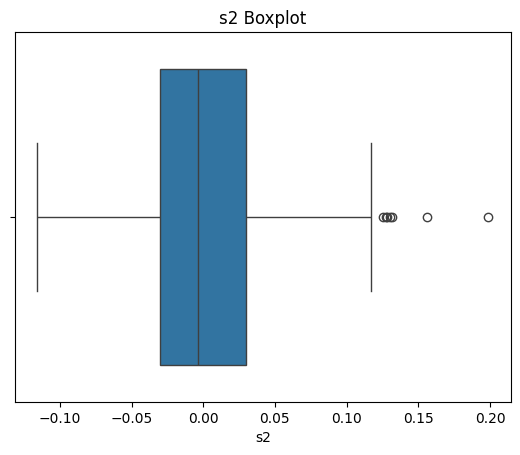

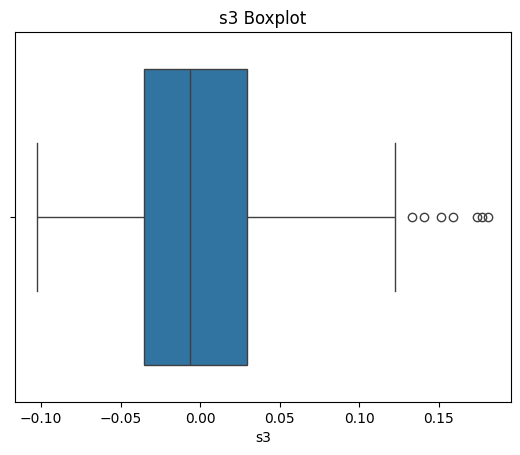

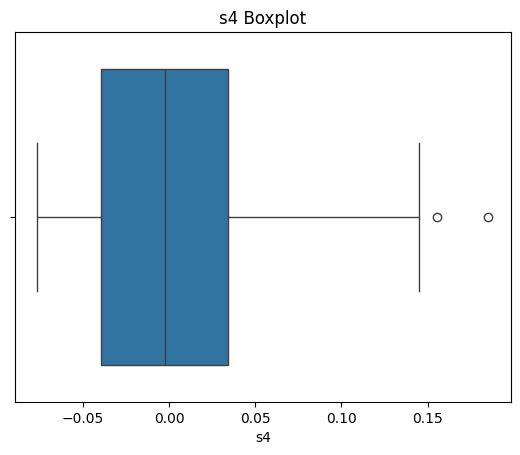

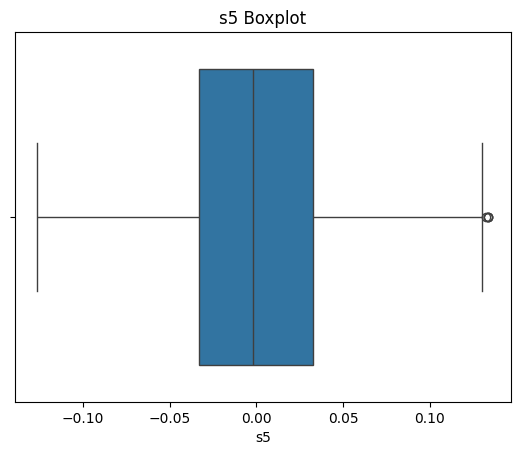

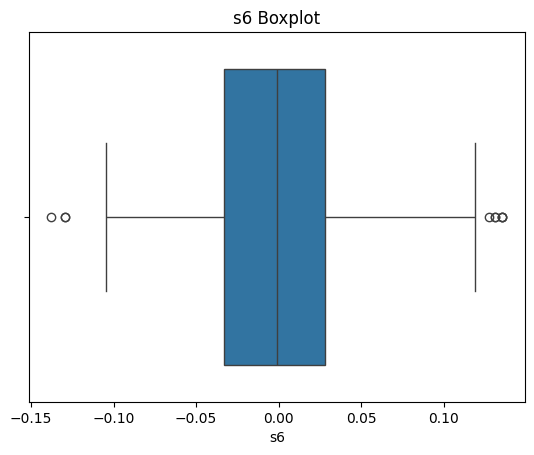

In [19]:
for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

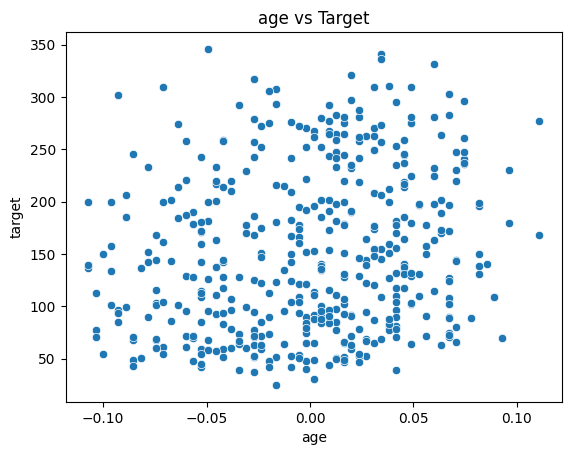

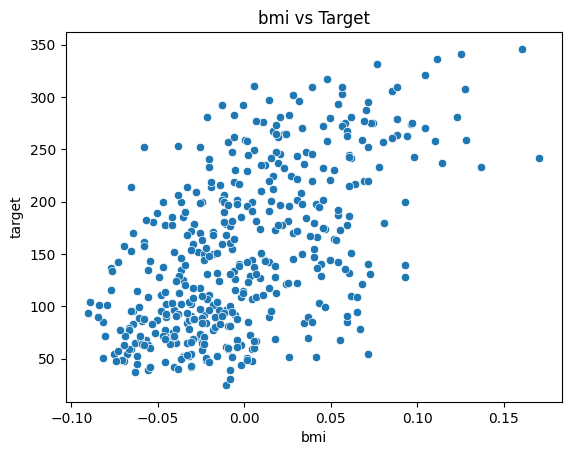

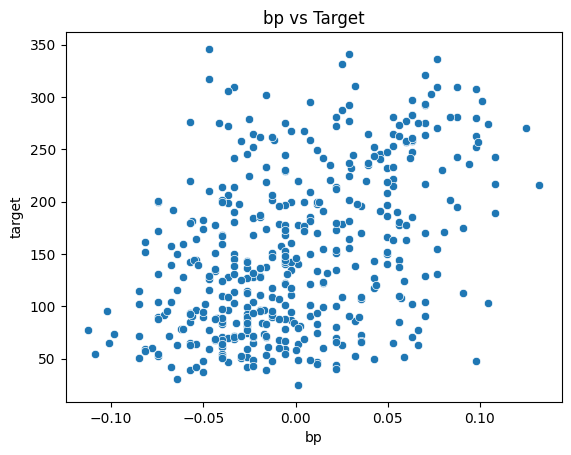

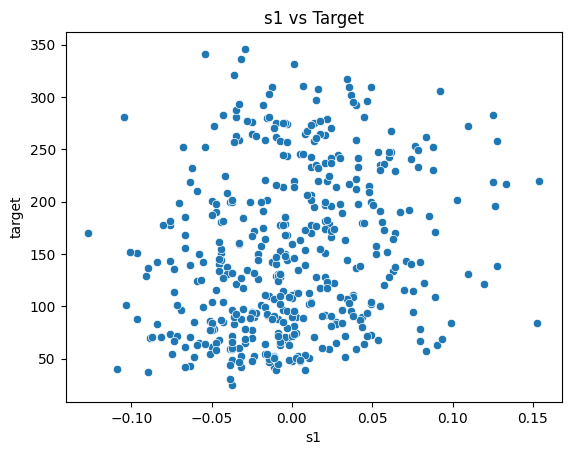

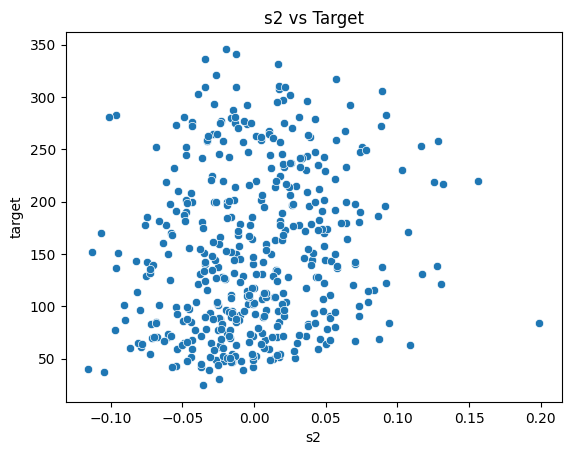

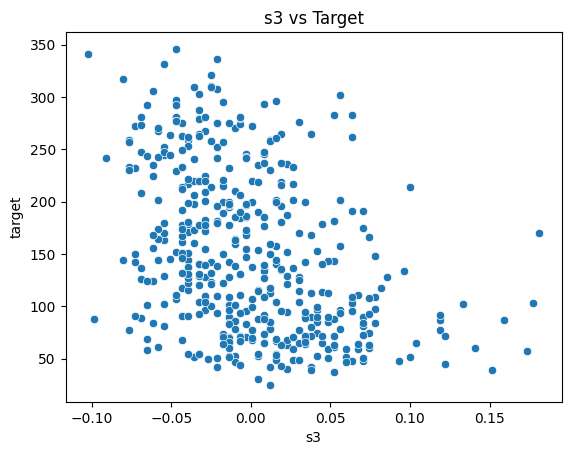

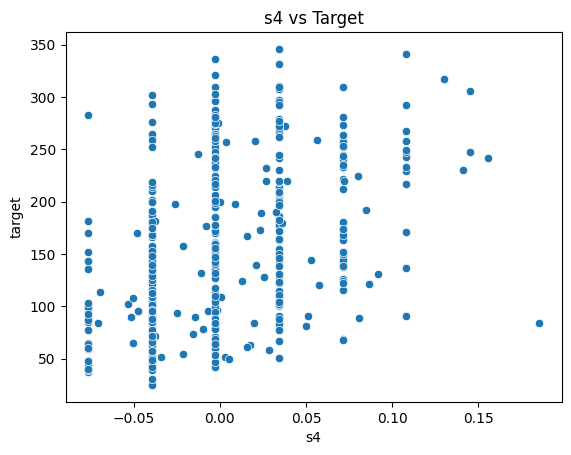

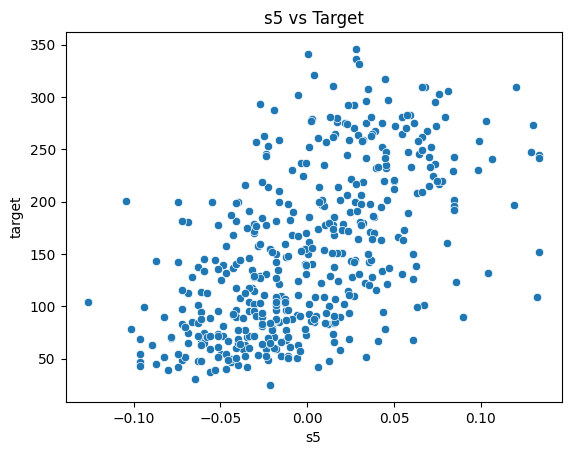

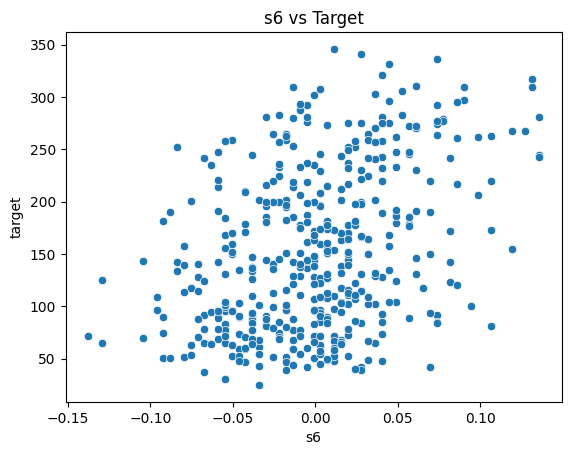

In [20]:
for col in numerical_cols:
    sns.scatterplot(x=df[col], y=df["target"])
    plt.title(f"{col} vs Target")
    plt.show()

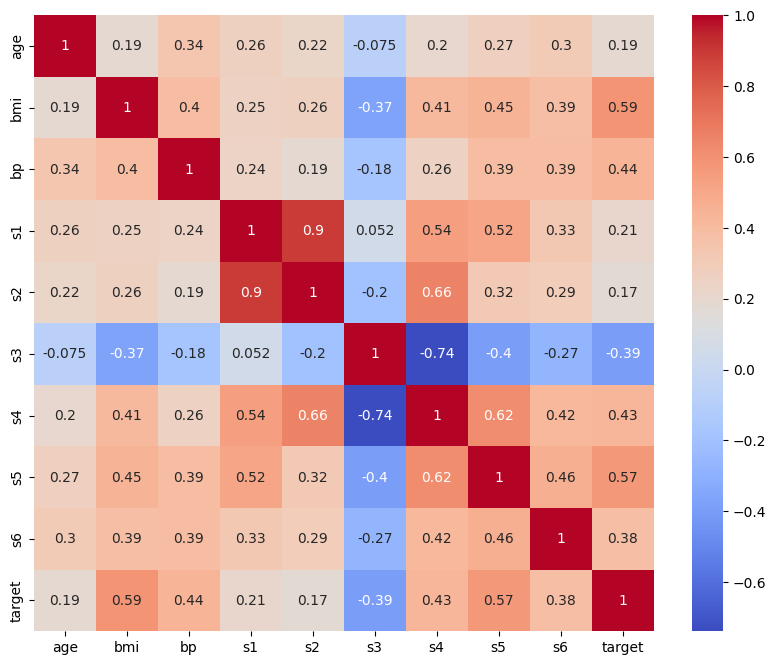

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols + ["target"]].corr(), annot=True, cmap="coolwarm")
plt.show()

In [22]:
X = df.drop("target", axis=1)
y = df["target"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [25]:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [26]:
pipeline_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.2f}")

In [29]:
evaluate(pipeline_lr)

MAE: 42.79
RMSE: 53.85
R2: 0.45


In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

grid_ridge.fit(X_train, y_train)

print("Best Alpha:", grid_ridge.best_params_)
evaluate(grid_ridge)

Best Alpha: {'model__alpha': 10}
MAE: 42.86
RMSE: 53.63
R2: 0.46


In [ ]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000))
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

grid_lasso = GridSearchCV(
    lasso_pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

grid_lasso.fit(X_train, y_train)

print("Best Alpha:", grid_lasso.best_params_)
evaluate(grid_lasso)



Best Alpha: {'model__alpha': 1}
MAE: 42.80
RMSE: 53.15
R2: 0.47


In [47]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=6,
    random_state=42
)

dt.fit(X_train, y_train)

evaluate(dt)

MAE: 47.47
RMSE: 60.59
R2: 0.31


In [48]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

evaluate(dt)

MAE: 54.53
RMSE: 70.55
R2: 0.06


In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

evaluate(rf)

MAE: 43.56
RMSE: 53.68
R2: 0.46


In [50]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

evaluate(rf)

MAE: 43.37
RMSE: 53.52
R2: 0.46


In [51]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

evaluate(xgb)

MAE: 45.92
RMSE: 56.43
R2: 0.40


In [52]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

pipeline_knn.fit(X_train, y_train)

evaluate(pipeline_knn)

MAE: 42.78
RMSE: 55.20
R2: 0.42


In [56]:
coeffs = grid_lasso.best_estimator_.named_steps["model"].coef_

import pandas as pd

pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coeffs
}).sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
2,bmi,26.219225
8,s5,22.636465
3,bp,15.657314
7,s4,3.420861
9,s6,2.098647
0,age,0.687032
5,s2,-0.000000
4,s1,-8.228172
6,s3,-9.024087
1,sex,-9.297519


In [57]:
grid_lasso.best_params_

{'model__alpha': 1}

In [58]:
import pandas as pd

results = {
    "Model": [
        "Lasso",
        "Ridge",
        "Random Forest",
        "Linear",
        "KNN",
        "XGBoost",
        "Decision Tree"
    ],
    "R2": [0.47, 0.46, 0.46, 0.45, 0.42, 0.40, 0.33],
    "RMSE": [53.15, 53.63, 53.52, 53.85, 55.20, 56.43, 59.74]
}

In [59]:
df_results = pd.DataFrame(results)

In [60]:
df_results = df_results.sort_values(by="R2", ascending=False)

In [61]:
print(df_results)

           Model    R2   RMSE
0          Lasso  0.47  53.15
1          Ridge  0.46  53.63
2  Random Forest  0.46  53.52
3         Linear  0.45  53.85
4            KNN  0.42  55.20
5        XGBoost  0.40  56.43
6  Decision Tree  0.33  59.74


## CLassical ML ENDs here


## Now we do Neural Network

In [63]:
!pip install torch torchvision torchaudio
import torch
import torch.nn as nn
import torch.optim as optim

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   - -------------------------------------- 3.4/114.6 MB 18.1 MB/s eta 0:00:07
   -- ------------------------------------- 7.6/114.6 MB 19.3 MB/s eta 0:00:06
   --- ------------------------------------ 11.3/114.6 MB 18.6 MB/s eta 0:00:06
   ---- ----------------------------------- 13.4/114.6 MB 16.6 MB/s eta 0:00:07
   ----- ---------------------------------- 15.2/114.6 MB 14.6 MB/s eta 0:00:07
   ----- ---------------------------------- 16.0/114.6 MB 12.9 MB/s eta 0:00:08
   ----- ---------------------------------- 16.8/114.6 MB 11.6 MB/s eta 0:00:09
   ------ --------------------------------- 18.4/114.6 MB 10.9 MB/s eta 0:00:09
   ------ --------------------------------- 19.9/114.6 MB 10.6 MB/s eta 0:00:09
   ------- -------------------------------- 22.3/114.6 MB 10.6 MB/s eta 0


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [81]:
import torch

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [82]:
import torch.nn as nn

class RegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.net(x)

In [83]:
model = RegressionNN()


In [90]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [91]:
epochs = 200

for epoch in range(epochs):
    
    # Forward pass
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 20, Loss: 9059.8047
Epoch 40, Loss: 5788.5747
Epoch 60, Loss: 4385.4736
Epoch 80, Loss: 3706.3875
Epoch 100, Loss: 3243.3679
Epoch 120, Loss: 2982.8066
Epoch 140, Loss: 2841.5337
Epoch 160, Loss: 2758.0872
Epoch 180, Loss: 2703.0625
Epoch 200, Loss: 2657.3445


In [92]:
model.eval()

with torch.no_grad():
    preds = model(X_test_t).numpy().flatten()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2:", r2_score(y_test, preds))

MAE: 42.636787157380176
RMSE: 52.9317638707751
R2: 0.4711794302124427
